####  Import necessary packages and the data

First run this command on your venv: pip install statsmodels

In [328]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime as dt
import math

from pandas.plotting import autocorrelation_plot
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import MinMaxScaler
from IPython.display import Image

%matplotlib inline
pd.options.display.float_format = '{:,.2f}'.format
np.set_printoptions(precision=2)
warnings.filterwarnings("ignore") # specify to ignore warning messages

In [329]:
energy = pd.read_csv('../data/data.csv')[['timestamp', 'load']]
energy['timestamp'] = pd.to_datetime(energy['timestamp'])
energy.set_index('timestamp', inplace=True)
energy.sort_index(inplace=True)
# energy.head(10)

#### Plot all the available energy data from January 2012 to December 2014

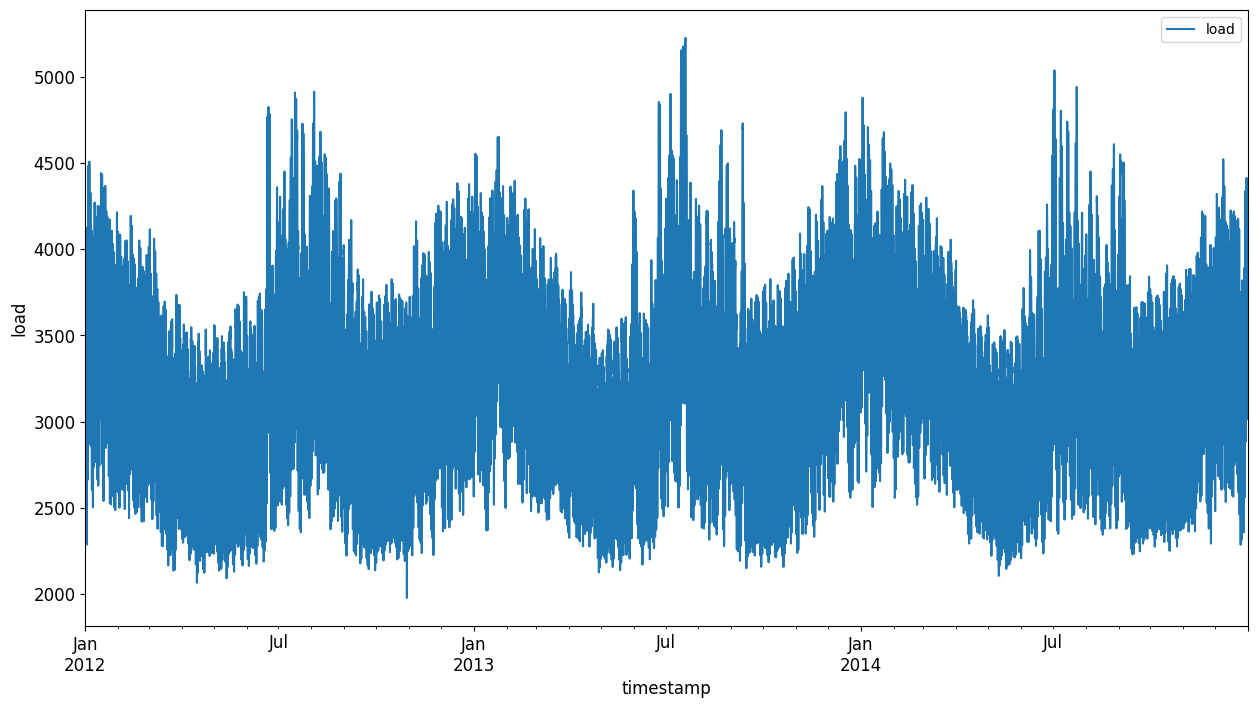

In [330]:
energy.plot(y='load', subplots=True, figsize=(15, 8), fontsize=12)
plt.xlabel('timestamp', fontsize=12)
plt.ylabel('load', fontsize=12)
plt.show()

#### Create training, testing datasets and plot it

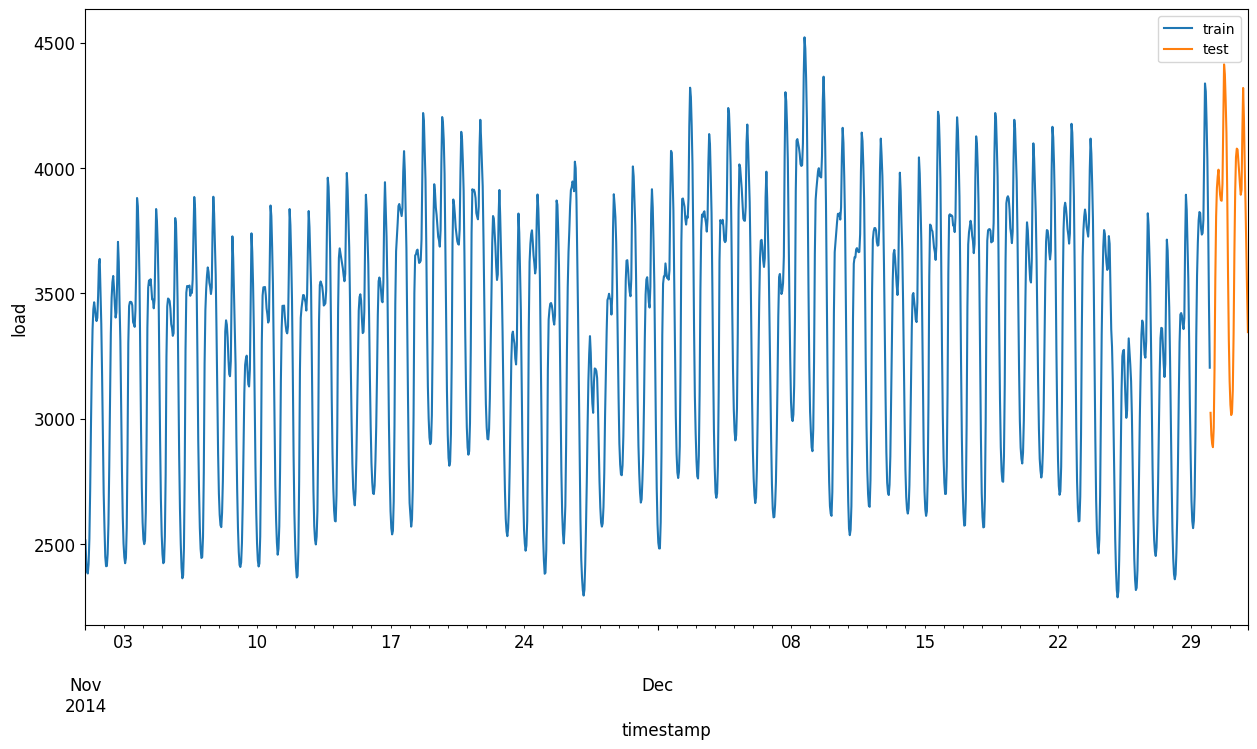

In [331]:
train_start_dt = '2014-11-01 00:00:00'
test_start_dt = '2014-12-30 00:00:00'

energy[(energy.index < test_start_dt) & (energy.index >= train_start_dt)][['load']].rename(columns={'load':'train'}) \
    .join(energy[test_start_dt:][['load']].rename(columns={'load':'test'}), how='outer') \
    .plot(y=['train', 'test'], figsize=(15, 8), fontsize=12)
plt.xlabel('timestamp', fontsize=12)
plt.ylabel('load', fontsize=12)
plt.show()

#### Prepare the data for training:

Filter the original dataset for the specified periods, keeping only the date and 'load' columns.

In [332]:
train = energy.copy()[(energy.index >= train_start_dt) & (energy.index < test_start_dt)][['load']]
test = energy.copy()[energy.index >= test_start_dt][['load']]

Scale both train and test data to be in the range (0, 1).

In [333]:
scaler = MinMaxScaler()
train['load'] = scaler.fit_transform(train)
test['load'] = scaler.transform(test)

Plot original, scaled test and train datas

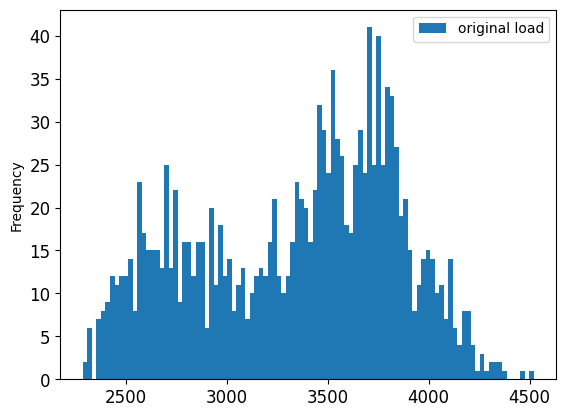

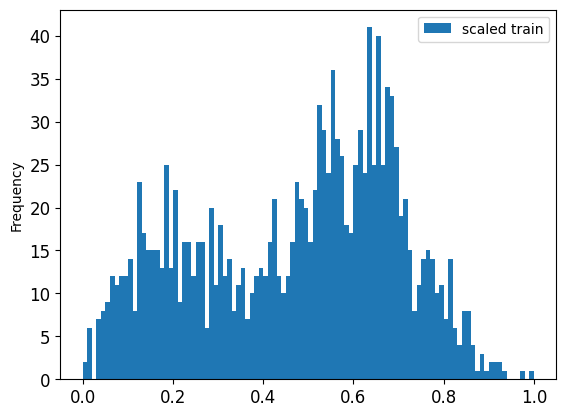

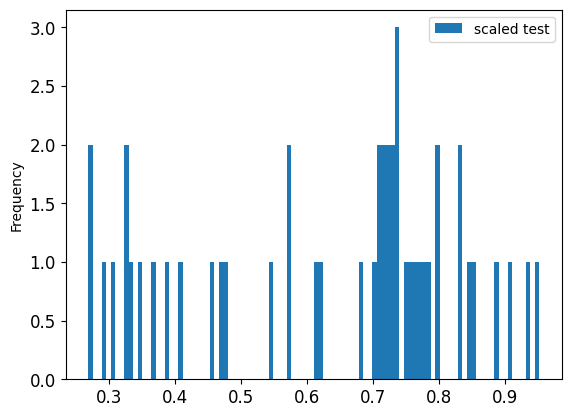

In [334]:
energy[(energy.index >= train_start_dt) & (energy.index < test_start_dt)][['load']].rename(columns={'load':'original load'}).plot.hist(bins=100, fontsize=12)
train.rename(columns={'load':'scaled train'}).plot.hist(bins=100, fontsize=12)
test.rename(columns={'load':'scaled test'}).plot.hist(bins=100, fontsize=12)
plt.show()

### Implementation of Seasonal ARIMA

1- Define the model by calling `SARIMAX()` and specifying the model parameters:
   the non-seasonal order (p, d, q) and the seasonal order (P, D, Q, s).

2- Train the model by calling the `fit()` function.

3- Generate predictions using the `forecast()` function and specifying the number of
   steps (forecast horizon).

**Note:** Our data is hourly, therefore one step corresponds to **one hour**.

#### 1. The Standart Order (p, d, q)

These three hyperparameters (4,1,0) focus on the immediate past.

p=4 (Autoregression): The model looks at the last 4 steps of data to predict the next hour. It assumes if it was high 1, 2, 3, or 4 steps ago, it will influence now.

d=1 (Differencing): subtracts the previous value from the current value to make the data "flat" (stationary) before calculating.

q=0 (Moving Average): This would look at past "shocks" or errors. Since it’s 0, your model ignores past forecast errors and only looks at past actual values.

#### 2. The Seasonal Order (P,D,Q,s)

These hyperparameters (1,1,0,24) focus on the 24-hour cycle.

P=1: The model looks at what happened exactly 24 steps ago (one full seasonal cycle) to help predict today.

D=1: This is "seasonal differencing." It compares today at 2 PM to yesterday at 2 PM to see if the overall daily pattern is shifting.

Q=0: Like the q above, this ignores "shocks" from 0 steps ago.

s=24: This defines your "heartbeat." It tells the model that the pattern repeats every 24 steps (hours).


$$
Y_t =
\underbrace{(\phi_1 Y_{t-1} + \phi_2 Y_{t-2} + \phi_3 Y_{t-3} + \phi_4 Y_{t-4})}_{\text{Close Past (AR)}}
+
\underbrace{(\Phi_1 Y_{t-24})}_{\text{Same Time Yesterday (Seasonal)}}
+
\underbrace{\epsilon_t}_{\text{Random Error}}
$$

### Build the first model

In [ ]:
order = (4, 1, 0)
seasonal_order = (1, 1, 0, 24)
model = SARIMAX(endog=train['load'], order=order, seasonal_order=seasonal_order)
results = model.fit()

In [336]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                               load   No. Observations:                 1416
Model:             SARIMAX(4, 1, 0)x(1, 1, 0, 24)   Log Likelihood                3477.208
Date:                            Tue, 10 Mar 2026   AIC                          -6942.416
Time:                                    23:28:21   BIC                          -6910.990
Sample:                                11-01-2014   HQIC                         -6930.665
                                     - 12-29-2014                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8395      0.016     52.557      0.000       0.808       0.871
ar.L2         -0.5179      0.034    -15.345      0.000      -0.584      -0.452
ar.L3          0.1535      0.044      3.462      0.001       0.067       0.240
ar.L4         -0.0768      0.036     -2.129      0.033      -0.148      -0.006
ar.S.L24      -0.2353      0.024     -9.866      0.000      -0.282      -0.189
sigma2         0.0004    8.3e-06     47.413      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):              1471.71
Prob(Q):                              0.86   Prob(JB):                         0.00
Heteroskedasticity (H):               0.84   Skew:                             0.13
Prob(H) (two-sided):                  0.07   Kurtosis:                         8.03
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Evaluate model

To evaluate the model, perform the so-called walk forward validation. In practice, time series models are re-trained each time a new data becomes available. This allows the model to make the best forecast at each time step.

Starting at the beginning of the time series using this technique, train the model on the train data set. Then make a prediction on the next time step. The prediction is evaluated against the known value. The training set is then expanded to include the known value and the process is repeated.

This process provides a more robust estimation of how the model will perform in practice. However, it comes at the computation cost of creating so many models. This is acceptable if the data is small or if the model is simple, but could be an issue at scale.

In [337]:
prediction_horizon = 3
test_shifted = test.copy()
test_shifted.index = pd.to_datetime(test_shifted.index)

for t in range(1, prediction_horizon):
    test_shifted['load+'+str(t)] = test_shifted['load'].shift(-t)

test_shifted = test_shifted.dropna(how='any')
test_shifted.head(5)

,load,load+1,load+2
timestamp,,,
2014-12-30 00:00:00,0.33,0.29,0.27
2014-12-30 01:00:00,0.29,0.27,0.27
2014-12-30 02:00:00,0.27,0.27,0.30
2014-12-30 03:00:00,0.27,0.30,0.41
2014-12-30 04:00:00,0.30,0.41,0.57


#### Make predictions on your test data using this sliding window approach in a loop the size of the test data length:

In [ ]:
%%time
training_window = 720 # dedicate 30 days (720 hours) for training

train_ts = train['load']
test_ts = test_shifted

history = [x for x in train_ts]
history = history[(-training_window):]

predictions = list()

order = (2, 1, 0)
seasonal_order = (1, 1, 0, 24)

for t in range(test_ts.shape[0]):
    model = SARIMAX(endog=history, order=order, seasonal_order=seasonal_order)
    model_fit = model.fit()
    yhat = model_fit.forecast(steps = prediction_horizon)
    predictions.append(yhat)
    obs = list(test_ts.iloc[t])
    # move the training window
    history.append(obs[0])
    history.pop(0)

In [339]:
eval_df = pd.DataFrame(predictions, columns=['t+'+str(t) for t in range(1, prediction_horizon+1)])
eval_df['timestamp'] = test_ts.index
eval_df = pd.melt(eval_df, id_vars='timestamp', value_name='prediction', var_name='h')

actual_matrix = test_shifted.iloc[:, :prediction_horizon].values
actuals = np.transpose(actual_matrix).ravel()

eval_df['actual'] = actuals
eval_df['prediction'] = scaler.inverse_transform(eval_df[['prediction']]).ravel()
eval_df['actual'] = scaler.inverse_transform(eval_df[['actual']]).ravel()
eval_df.head()

,timestamp,h,prediction,actual
0,2014-12-30 00:00:00,t+1,"3,008.91","3,023.00"
1,2014-12-30 01:00:00,t+1,"2,955.04","2,935.00"
2,2014-12-30 02:00:00,t+1,"2,900.12","2,899.00"
3,2014-12-30 03:00:00,t+1,"2,917.72","2,886.00"
4,2014-12-30 04:00:00,t+1,"2,947.01","2,963.00"


In [ ]:
if(prediction_horizon > 1):
    eval_df['APE'] = (eval_df['prediction'] - eval_df['actual']).abs() / eval_df['actual']
print('Absolute Percentage Error: ', eval_df['APE'].mean())

APE:  0.011510646229988266


In [341]:
one_step_df = eval_df[eval_df['h'] == 't+1']
mape = ((one_step_df['prediction'] - one_step_df['actual']).abs() / one_step_df['actual']).mean() * 100
print('One step forecast MAPE: {:.2f}%'.format(mape))

One step forecast MAPE: 0.56%


In [342]:
multi_step_df = eval_df[eval_df['h'] != 't+1']
multi_step_mape = multi_step_df['APE'].mean() * 100
print('Multi-step forecast MAPE: {:.2f}%'.format(multi_step_mape))

Multi-step forecast MAPE: 1.44%


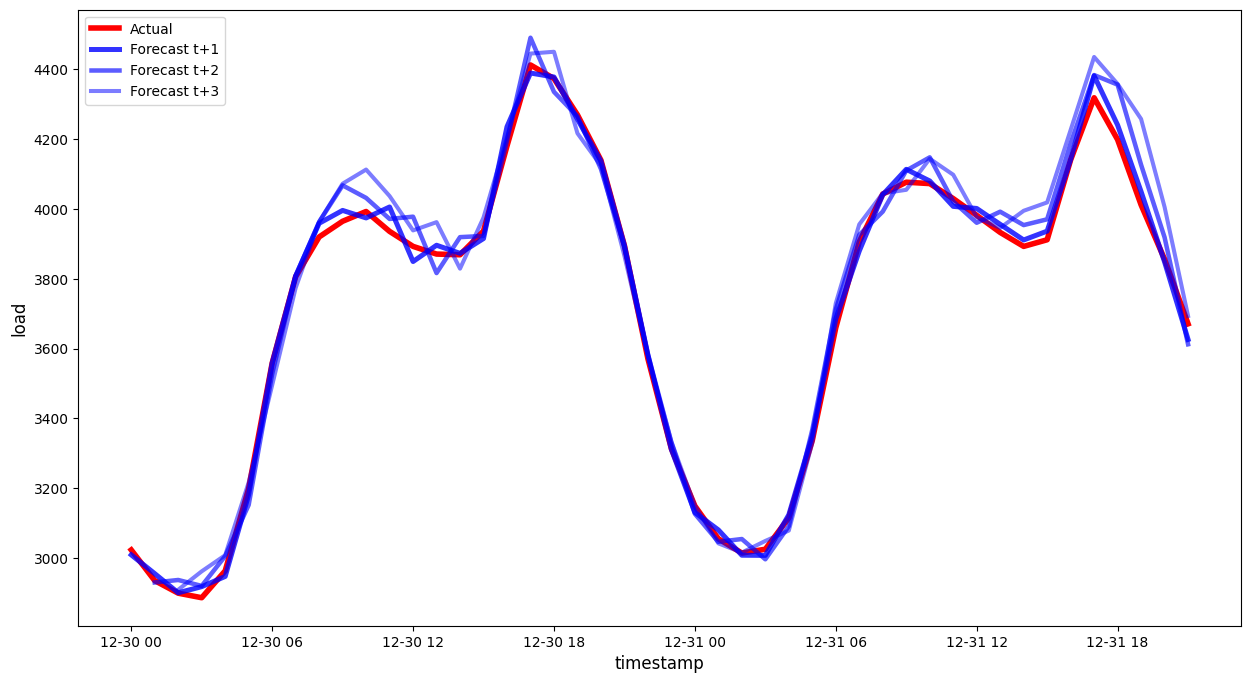

In [343]:
if(prediction_horizon == 1):
    ## Plotting single step forecast
    eval_df.plot(x='timestamp', y=['actual', 'prediction'], style=['r', 'b'], figsize=(15, 8))

else:
    ## Plotting multi step forecast
    plot_df = eval_df[(eval_df.h=='t+1')][['timestamp', 'actual']]
    for t in range(1, prediction_horizon+1):
        plot_df['t+'+str(t)] = eval_df[(eval_df.h=='t+'+str(t))]['prediction'].values

    fig, ax = plt.subplots(figsize=(15, 8))
    ax.plot(plot_df['timestamp'], plot_df['actual'], color='red', linewidth=4.0, label='Actual')
    for t in range(1, prediction_horizon+1):
        x = plot_df['timestamp'][(t-1):]
        y = plot_df['t+'+str(t)][0:len(x)]
        ax.plot(x, y, color='blue', linewidth=4*math.pow(.9,t), alpha=math.pow(0.8,t), label=f'Forecast t+{t}')

    ax.legend(loc='best')

plt.xlabel('timestamp', fontsize=12)
plt.ylabel('load', fontsize=12)
plt.show()

Training with new hyperparameters

In [ ]:
%%time
training_window = 1440 # dedicate 60 days (1440 hours) for training
train_ts = train['load']
test_ts = test_shifted
history = [x for x in train_ts]
history = history[(-training_window):]
predictions = list()
order = (2, 1, 0)
seasonal_order = (1, 1, 0, 24)

for t in range(test_ts.shape[0]):
    model = SARIMAX(endog=history, order=order, seasonal_order=seasonal_order)
    model_fit = model.fit()
    yhat = model_fit.forecast(steps = prediction_horizon)
    predictions.append(yhat)
    obs = list(test_ts.iloc[t])
    # move the training window
    history.append(obs[0])
    history.pop(0)

eval_df = pd.DataFrame(predictions, columns=['t+'+str(t) for t in range(1, prediction_horizon+1)])
eval_df['timestamp'] = test_ts.index
eval_df = pd.melt(eval_df, id_vars='timestamp', value_name='prediction', var_name='h')

actual_matrix = test_shifted.iloc[:, :prediction_horizon].values
actuals = np.transpose(actual_matrix).ravel()

eval_df['actual'] = actuals
eval_df['prediction'] = scaler.inverse_transform(eval_df[['prediction']]).ravel()
eval_df['actual'] = scaler.inverse_transform(eval_df[['actual']]).ravel()

if(prediction_horizon > 1):
    eval_df['APE'] = (eval_df['prediction'] - eval_df['actual']).abs() / eval_df['actual']
    print(eval_df.groupby('h')['APE'].mean())

one_step_df = eval_df[eval_df['h'] == 't+1']
mape = ((one_step_df['prediction'] - one_step_df['actual']).abs() / one_step_df['actual']).mean() * 100
multi_step_df = eval_df[eval_df['h'] != 't+1']
multi_step_mape = multi_step_df['APE'].mean() * 100

In [345]:
# Already computed in the previous cell; keeping this as a compact inspection cell
eval_df.head()

,timestamp,h,prediction,actual,APE
0,2014-12-30 00:00:00,t+1,"3,008.38","3,023.00",0.00
1,2014-12-30 01:00:00,t+1,"2,952.63","2,935.00",0.01
2,2014-12-30 02:00:00,t+1,"2,899.58","2,899.00",0.00
3,2014-12-30 03:00:00,t+1,"2,916.88","2,886.00",0.01
4,2014-12-30 04:00:00,t+1,"2,946.67","2,963.00",0.01


One step forecast MAPE: 0.56%
Multi-step forecast MAPE: 1.45%


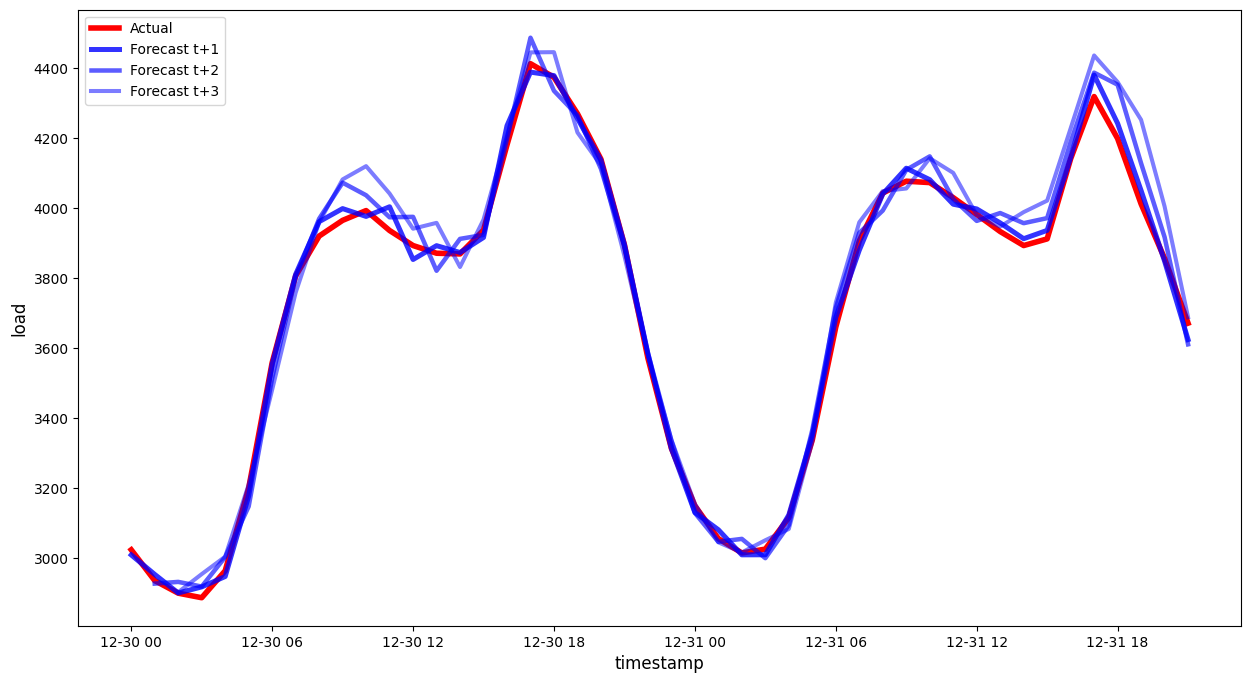

In [346]:
print('One step forecast MAPE: {:.2f}%'.format(mape))
print('Multi-step forecast MAPE: {:.2f}%'.format(multi_step_mape))

if(prediction_horizon == 1):
    ## Plotting single step forecast
    eval_df.plot(x='timestamp', y=['actual', 'prediction'], style=['r', 'b'], figsize=(15, 8))

else:
    ## Plotting multi step forecast
    plot_df = eval_df[(eval_df.h=='t+1')][['timestamp', 'actual']]
    for t in range(1, prediction_horizon+1):
        plot_df['t+'+str(t)] = eval_df[(eval_df.h=='t+'+str(t))]['prediction'].values

    fig, ax = plt.subplots(figsize=(15, 8))
    ax.plot(plot_df['timestamp'], plot_df['actual'], color='red', linewidth=4.0, label='Actual')
    for t in range(1, prediction_horizon+1):
        x = plot_df['timestamp'][(t-1):]
        y = plot_df['t+'+str(t)][0:len(x)]
        ax.plot(x, y, color='blue', linewidth=4*math.pow(.9,t), alpha=math.pow(0.8,t), label=f'Forecast t+{t}')

    ax.legend(loc='best')

plt.xlabel('timestamp', fontsize=12)
plt.ylabel('load', fontsize=12)
plt.show()